<a href="https://colab.research.google.com/github/CristianPetrica/ICI_Practica_UTM/blob/Cristian-Petrica/ICI_3_Practica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Preparation**

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import tensorflow as tf
import random

import os
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [2]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install kaggle
!kaggle datasets download -d zarif98sjs/gait-in-parkinsons-disease
!unzip gait-in-parkinsons-disease.zip -d gait_data
import os
input_dir = 'gait_data'
print(len(os.listdir(input_dir)))  # Afișează numărul de fișiere din director

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/zarif98sjs/gait-in-parkinsons-disease
License(s): unknown
Archive:  gait-in-parkinsons-disease.zip
  inflating: gait_data/GaCo01_01.txt  
  inflating: gait_data/GaCo02_01.txt  
  inflating: gait_data/GaCo02_02.txt  
  inflating: gait_data/GaCo03_01.txt  
  inflating: gait_data/GaCo03_02.txt  
  inflating: gait_data/GaCo04_01.txt  
  inflating: gait_data/GaCo04_02.txt  
  inflating: gait_data/GaCo05_01.txt  
  inflating: gait_data/GaCo05_02.txt  
  inflating: gait_data/GaCo06_01.txt  
  inflating: gait_data/GaCo06_02.txt  
  inflating: gait_data/GaCo07_01.txt  
  inflating: gait_data/GaCo07_02.txt  
  inflating: gait_data/GaCo08_01.txt  
  inflating: gait_data/GaCo08_02.txt  
  inflating: gait_data/GaCo09_01.txt  
  inflating: gait_data/GaCo09_02.txt  
  inflating: gait_data/GaCo10_01.txt  
  inflating: gait_data/GaCo10_02.txt  
  inflating: gait_data/GaCo11_01.txt  
  inflating: gait_data/GaCo12_01.txt  
  i

In [3]:

features = ['Time', 'L1' , 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8',
            'R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8',
            'Total_Force_Left', 'Total_Force_Right']

!mkdir -p CSV
!mkdir -p date  # pentru demographics

i = 0
for file in os.listdir(input_dir):
    i += 1
    if file == 'demographics.txt':
        df = pd.read_csv(os.path.join(input_dir, file), sep='\t', on_bad_lines='skip')
        name = 'date/' + file.split('.')[0] + '.csv'
        df.to_csv(name, index=False)
    elif file[:2] in ['Ga', 'Ju', 'Si']:
        df = pd.read_csv(os.path.join(input_dir, file), header=None, sep='\t', on_bad_lines='skip')
        df.columns = features
        name = 'CSV/' + file.split('.')[0] + '.csv'
        df.to_csv(name, index=False)

print(i)


309


# **Data View**

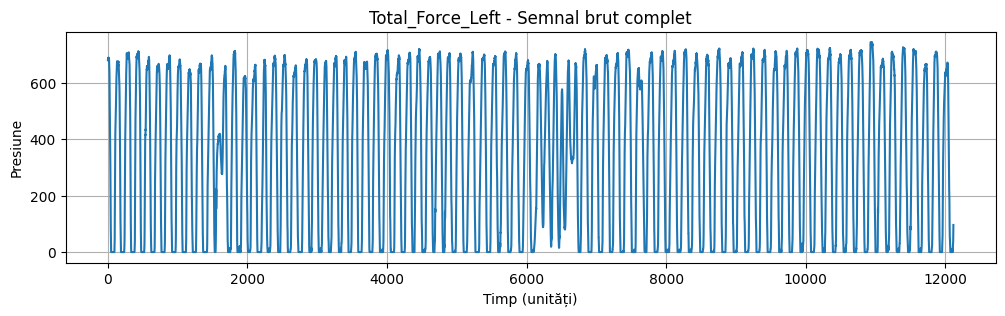

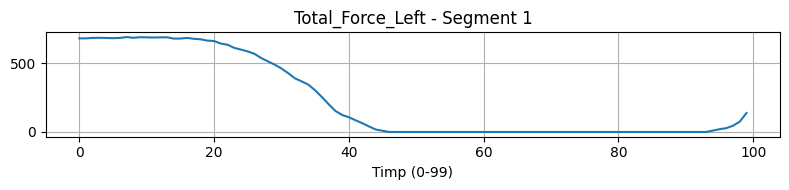

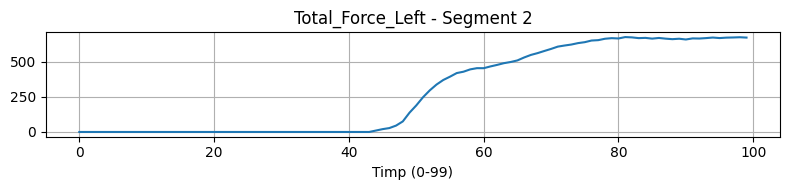

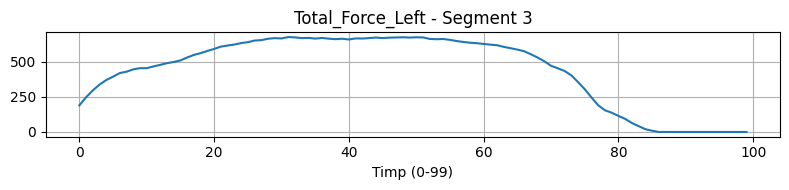

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ========================
# Parametri de segmentare
# ========================
SEGMENT_SIZE = 100
STEP_SIZE = 50
SENSOR = 'Total_Force_Left'  # poți schimba în 'L1', 'R5' etc.

# ========================
# Segmentare simplă
# ========================
def segment_signal(data, segment_size=100, step=50):
    segments = []
    for start in range(0, len(data) - segment_size, step):
        segment = data[start:start + segment_size]
        if len(segment) == segment_size:
            segments.append(segment)
    return np.array(segments)

# ========================
# 1. Încarcă datele unui pacient
# ========================
file_path = "CSV/GaPt03_01.csv"  # <- pune aici calea ta
df = pd.read_csv(file_path)

# ========================
# 2. Afișează semnalul brut
# ========================
plt.figure(figsize=(12, 3))
plt.plot(df[SENSOR])
plt.title(f"{SENSOR} - Semnal brut complet")
plt.xlabel("Timp (unități)")
plt.ylabel("Presiune")
plt.grid(True)
plt.show()

# ========================
# 3. Aplică segmentarea
# ========================
segments = segment_signal(df[SENSOR].values, segment_size=SEGMENT_SIZE, step=STEP_SIZE)

# ========================
# 4. Afișează primele 3 segmente
# ========================
for i in range(min(3, len(segments))):
    plt.figure(figsize=(8, 2))
    plt.plot(segments[i])
    plt.title(f"{SENSOR} - Segment {i+1}")
    plt.xlabel("Timp (0-99)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# **Predict Pe Sanatos vs Parkinson**

Model: "functional_24"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_24      │ (None, 100, 18)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_48 (Conv1D)  │ (None, 98, 64)    │      3,520 │ input_layer_24[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 98, 64)    │        256 │ conv1d_48[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_49 (Conv1D)  │ (None, 96, 128)   │     24,704 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 128)   │        512 │ conv1d_49[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_24    │ (None, 48, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 48, 128)   │     99,008 │ max_pooling1d_24… │
│ (MultiHeadAttentio… │                   │            │ max_pooling1d_24… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_24 (Add)        │ (None, 48, 128)   │          0 │ max_pooling1d_24… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 48, 128)   │        256 │ add_24[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_48 (Dense)    │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_49          │ (None, 64)        │          0 │ dense_48[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_49 (Dense)    │ (None, 1)         │         65 │ dropout_49[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 136,577 (533.50 KB)

 Trainable params: 136,193 (532.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
1654/1654 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.6119 - loss: 0.6635 - val_accuracy: 0.7386 - val_loss: 0.5330 - learning_rate: 1.0000e-05
Epoch 2/100
1654/1654 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7824 - loss: 0.4874 - val_accuracy: 0.7837 - val_loss: 0.4644 - learning_rate: 1.0000e-05
Epoch 3/100
1654/1654 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8418 - loss: 0.3937 - val_accuracy: 0.8133 - val_loss: 0.4255 - learning_rate: 1.0000e-05
Epoch 4/100
1654/1654 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8799 - loss: 0.3270 - val_accuracy: 0.8298 - val_loss: 0.4015 - learning_rate: 1.0000e-05
Epoch 5/100
1654/1654 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9033 - loss: 0.2701 - val_accuracy: 0.8468 - val_loss: 0.3868 - learning_rate: 1.0000e-05
Epoch 6/100
1654/1654 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9266 - loss: 0.2172 - val_accuracy: 0.8627 - val_loss: 0.3743 - learning_rate: 1.0000e-05
Epoch 7/100
1654/1654 ━━━━━━━━━━━━━━━━━━━━ 1

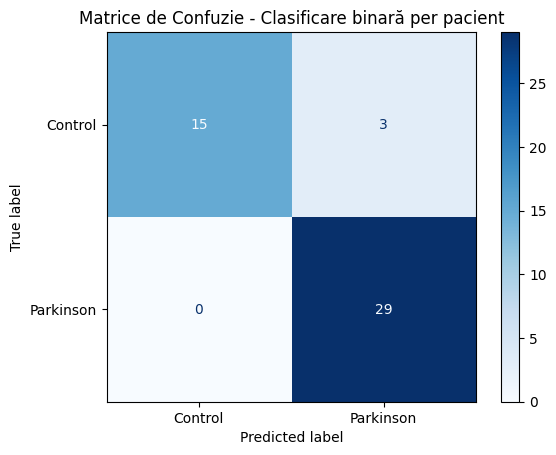

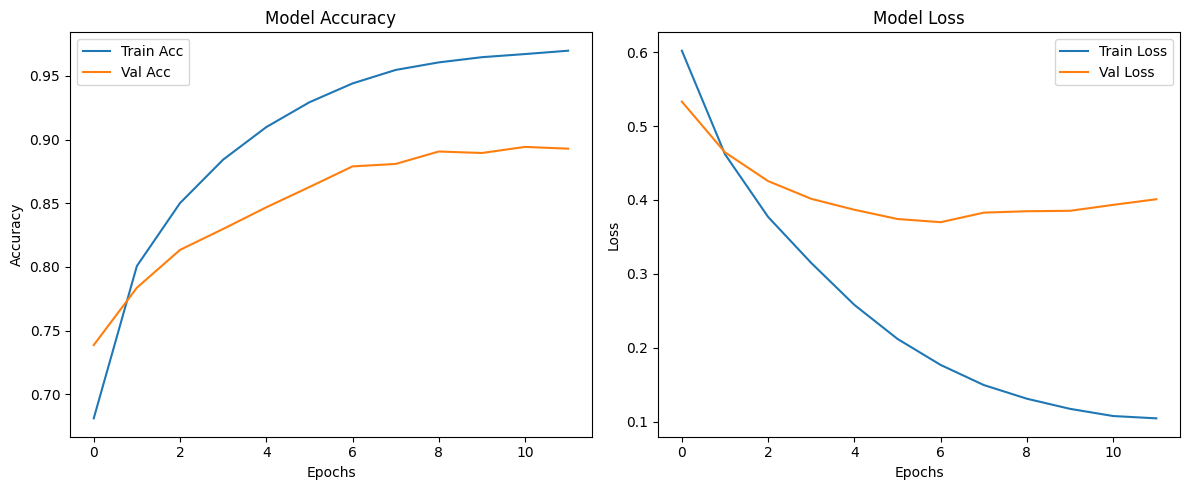

In [ ]:
# Clasificare binara Parkinson vs Control folosind ConvNet + Transformer cu îmbunătățiri anti-overfitting
# Cerinte: TensorFlow >= 2.0, numpy, scikit-learn

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import os
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

# Parametri
SEGMENT_SIZE = 100
STEP_SIZE = 50
NUM_SENSORS = 18
CSV_FOLDER = "CSV"

# ========================
# Funcții pentru procesare
# ========================
def segment_signal(data, segment_size=100, step=50):
    segments = []
    for start in range(0, len(data) - segment_size, step):
        segment = data[start:start + segment_size]
        if segment.shape[0] == segment_size:
            segments.append(segment)
    return np.array(segments)

def load_patient_data(csv_folder):
    patient_data = []
    for file in os.listdir(csv_folder):
        if not file.endswith(".csv"):
            continue
        label = 1 if "Pt" in file else 0
        df = pd.read_csv(os.path.join(csv_folder, file))
        if df.shape[0] < SEGMENT_SIZE:
            continue
        sensor_data = df[[
            'L1','L2','L3','L4','L5','L6','L7','L8',
            'R1','R2','R3','R4','R5','R6','R7','R8',
            'Total_Force_Left','Total_Force_Right'
        ]].values
        patient_data.append((sensor_data, label, file.split("_")[0]))
    return patient_data

def segment_all(patients):
    X, y, pids = [], [], []
    for data, label, pid in patients:
        segments = segment_signal(data, segment_size=SEGMENT_SIZE, step=STEP_SIZE)
        X.extend(segments)
        y.extend([label] * len(segments))
        pids.extend([pid] * len(segments))
    return np.array(X), np.array(y), np.array(pids)

def shuffle_segments(X, y, pids):
    idx = np.arange(len(X))
    np.random.shuffle(idx)
    return X[idx], y[idx], pids[idx]

# ========================
# Arhitectura modelului cu regularizare
# ========================
def build_model(input_shape):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=regularizers.l2(1e-5))(inputs)
    x = layers.BatchNormalization()(x)

    x = layers.Conv1D(128, kernel_size=3, activation='relu', kernel_regularizer=regularizers.l2(1e-5))(x)
    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling1D(pool_size=2)(x)

    attention_output = layers.MultiHeadAttention(num_heads=6, key_dim=32)(x, x)
    x = layers.Add()([x, attention_output])
    x = layers.LayerNormalization()(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    from tensorflow.keras.optimizers import Adam
    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# ========================
# Încarcă și pregătește datele
# ========================
patient_data = load_patient_data(CSV_FOLDER)
train_patients, test_patients = train_test_split(
    patient_data,
    test_size=0.2,
    stratify=[label for _, label, _ in patient_data],
    random_state=42
)

X_train, y_train, pids_train = segment_all(train_patients)
X_train, y_train, pids_train = shuffle_segments(X_train, y_train, pids_train)
X_test, y_test, pids_test = segment_all(test_patients)

# Normalizează datele
scaler = StandardScaler()
X_train = X_train.reshape(-1, SEGMENT_SIZE * NUM_SENSORS)
X_train = scaler.fit_transform(X_train)
X_train = X_train.reshape(-1, SEGMENT_SIZE, NUM_SENSORS)

X_test = X_test.reshape(-1, SEGMENT_SIZE * NUM_SENSORS)
X_test = scaler.transform(X_test)
X_test = X_test.reshape(-1, SEGMENT_SIZE, NUM_SENSORS)

# ========================
# Antrenare model
# ========================
model = build_model(input_shape=(SEGMENT_SIZE, NUM_SENSORS))
model.summary()

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, min_delta=0.001)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stop, lr_scheduler]
)

# ========================
# Evaluare per pacient
# ========================

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

votes = defaultdict(list)
truth = {}
for pid, pred, true in zip(pids_test, y_pred, y_test):
    votes[pid].append(pred)
    truth[pid] = true

final_preds = []
final_truths = []
for pid in votes:
    final_preds.append(int(np.round(np.mean(votes[pid]))))
    final_truths.append(truth[pid])

print("\nEvaluare per pacient:")
print(classification_report(final_truths, final_preds))

# Matrice de confuzie
cm = confusion_matrix(final_truths, final_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Control", "Parkinson"])
disp.plot(cmap="Blues")
plt.title("Matrice de Confuzie - Clasificare binară per pacient")
plt.grid(False)
plt.show()

# ========================
# Plot evoluție antrenament
# ========================

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.tight_layout()
plt.show()


# **Predict Pe 4 Clase**

Epoch 1/100
1632/1632 ━━━━━━━━━━━━━━━━━━━━ 185s 51ms/step - accuracy: 0.3027 - loss: 1.3376 - val_accuracy: 0.3928 - val_loss: 1.3267 - learning_rate: 0.0010
Epoch 2/100
1632/1632 ━━━━━━━━━━━━━━━━━━━━ 74s 26ms/step - accuracy: 0.5478 - loss: 0.9999 - val_accuracy: 0.5116 - val_loss: 1.1386 - learning_rate: 0.0010
Epoch 3/100
1632/1632 ━━━━━━━━━━━━━━━━━━━━ 83s 27ms/step - accuracy: 0.6503 - loss: 0.8312 - val_accuracy: 0.5395 - val_loss: 1.1393 - learning_rate: 0.0010
Epoch 4/100
1632/1632 ━━━━━━━━━━━━━━━━━━━━ 84s 28ms/step - accuracy: 0.6977 - loss: 0.7429 - val_accuracy: 0.5816 - val_loss: 1.0353 - learning_rate: 0.0010
Epoch 5/100
1632/1632 ━━━━━━━━━━━━━━━━━━━━ 79s 26ms/step - accuracy: 0.7246 - loss: 0.6807 - val_accuracy: 0.6063 - val_loss: 1.0131 - learning_rate: 0.0010
Epoch 6/100
1632/1632 ━━━━━━━━━━━━━━━━━━━━ 82s 26ms/step - accuracy: 0.7402 - loss: 0.6424 - val_accuracy: 0.5948 - val_loss: 0.9843 - learning_rate: 0.0010
Epoch 7/100
1632/1632 ━━━━━━━━━━━━━━━━━━━━ 82s 26ms/step 

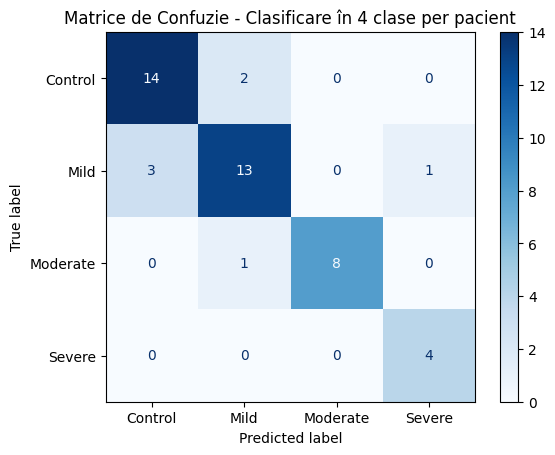

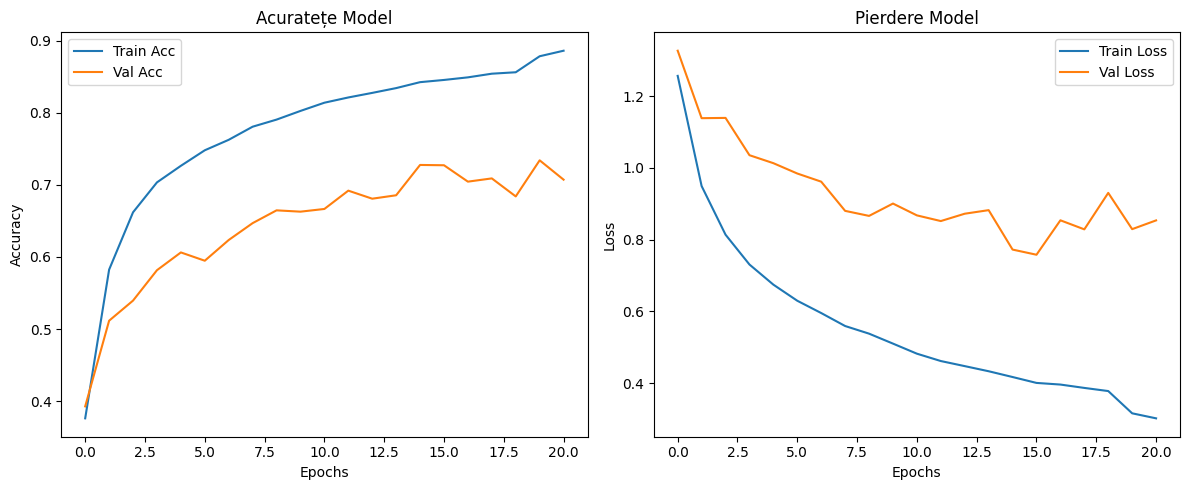

In [ ]:
# Model complet: ConvNet + Transformer + evaluare + grafic

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Parametri
SEGMENT_SIZE = 100
STEP_SIZE = 50
NUM_SENSORS = 18
CSV_FOLDER = "CSV"
DEMO_PATH = "date/demographics.csv"

# Segmentare
def segment_signal(data, segment_size=100, step=50):
    segments = []
    for start in range(0, len(data) - segment_size, step):
        segment = data[start:start + segment_size]
        if segment.shape[0] == segment_size:
            segments.append(segment)
    return np.array(segments)

# Funcție mapare severitate

def map_severity(val):
    if pd.isna(val) or val == 0:
        return 0  # Control
    elif val == 2:
        return 1  # Mild
    elif val == 2.5:
        return 2  # Moderate
    else:
        return 3  # Severe (>=3)

# Load demografie
demo_df = pd.read_csv(DEMO_PATH)
demo_df['HoehnYahr'] = demo_df['HoehnYahr'].fillna(0)
patient_severity = {
    row['ID']: map_severity(row['HoehnYahr'])
    for _, row in demo_df.iterrows()
}

# Load CSV-uri pacienți
def load_patient_data_multiclass(csv_folder):
    patient_data = []
    for file in os.listdir(csv_folder):
        if not file.endswith(".csv"):
            continue
        patient_id = file.split("_")[0]
        label = patient_severity.get(patient_id, None)
        if label is None:
            continue
        df = pd.read_csv(os.path.join(csv_folder, file))
        if df.shape[0] < SEGMENT_SIZE:
            continue
        sensor_data = df[[
            'L1','L2','L3','L4','L5','L6','L7','L8',
            'R1','R2','R3','R4','R5','R6','R7','R8',
            'Total_Force_Left','Total_Force_Right'
        ]].values
        patient_data.append((sensor_data, label, patient_id))
    return patient_data

# Segmentare + shuffle
def segment_all(patients):
    X, y, pids = [], [], []
    for data, label, pid in patients:
        segments = segment_signal(data, segment_size=SEGMENT_SIZE, step=STEP_SIZE)
        X.extend(segments)
        y.extend([label] * len(segments))
        pids.extend([pid] * len(segments))
    return np.array(X), np.array(y), np.array(pids)

def shuffle_segments(X, y, pids):
    idx = np.arange(len(X))
    np.random.shuffle(idx)
    return X[idx], y[idx], pids[idx]

# === Model ConvNet + Transformer ===
def build_conv_transformer_model(input_shape, num_classes=4, num_sensors=18):
    inputs = tf.keras.Input(shape=input_shape)
    conv_outputs = []
    for i in range(num_sensors):
        x = layers.Lambda(lambda z: z[:, :, i:i+1])(inputs)
        x = layers.Conv1D(8, 3, activation='relu', padding='valid')(x)
        x = layers.Conv1D(16, 3, activation='relu', padding='valid')(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Conv1D(16, 3, activation='relu', padding='valid')(x)
        x = layers.Conv1D(16, 3, activation='relu', padding='valid')(x)
        x = layers.MaxPooling1D(2)(x)
        conv_outputs.append(x)

    temporal_outputs = []
    for x in conv_outputs:
        x = layers.LayerNormalization()(x)
        attn = layers.MultiHeadAttention(num_heads=2, key_dim=16)(x, x)
        x = layers.Add()([x, attn])
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dense(10, activation='selu')(x)
        temporal_outputs.append(x)

    spatial_input = layers.Concatenate()(temporal_outputs)
    spatial_input = layers.Reshape((num_sensors, 10))(spatial_input)
    x = layers.LayerNormalization()(spatial_input)
    attn = layers.MultiHeadAttention(num_heads=2, key_dim=10)(x, x)
    x = layers.Add()([x, attn])
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=tf.keras.optimizers.Nadam(learning_rate=1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# === Antrenare ===
patient_data = load_patient_data_multiclass(CSV_FOLDER)
train_patients, test_patients = train_test_split(
    patient_data, test_size=0.2, stratify=[p[1] for p in patient_data], random_state=42)
X_train, y_train, pids_train = segment_all(train_patients)
X_train, y_train, pids_train = shuffle_segments(X_train, y_train, pids_train)
X_test, y_test, pids_test = segment_all(test_patients)

# Standardizare
scaler = StandardScaler()
X_train = X_train.reshape(-1, SEGMENT_SIZE * NUM_SENSORS)
X_train = scaler.fit_transform(X_train)
X_train = X_train.reshape(-1, SEGMENT_SIZE, NUM_SENSORS)
X_test = X_test.reshape(-1, SEGMENT_SIZE * NUM_SENSORS)
X_test = scaler.transform(X_test)
X_test = X_test.reshape(-1, SEGMENT_SIZE, NUM_SENSORS)

# One-hot encoding
num_classes = 4
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# Clasa ponderată
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

# Model + callbacks
model = build_conv_transformer_model(input_shape=(SEGMENT_SIZE, NUM_SENSORS), num_classes=num_classes)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=100,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

# === Evaluare per pacient ===
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

votes = defaultdict(list)
truth = {}
for pid, pred, true in zip(pids_test, y_pred, y_test):
    votes[pid].append(pred)
    truth[pid] = true

final_preds, final_truths = [], []
for pid in votes:
    final_preds.append(np.bincount(votes[pid]).argmax())
    final_truths.append(truth[pid])

# === Raport + matrice de confuzie ===
report_text = classification_report(
    final_truths, final_preds,
    labels=[0, 1, 2, 3],
    target_names=['Control', 'Mild', 'Moderate', 'Severe'],
    zero_division=0
)
print("\nEvaluare per pacient:\n", report_text)

cm = confusion_matrix(final_truths, final_preds, labels=[0,1,2,3])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Control', 'Mild', 'Moderate', 'Severe'])
disp.plot(cmap='Blues')
plt.title("Matrice de Confuzie - Clasificare în 4 clase per pacient")
plt.grid(False)
plt.show()

# === Plot: evoluția loss și accuracy ===
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Acuratețe Model')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Pierdere Model')
plt.legend()
plt.tight_layout()
plt.show()

# **EXTRA**

In [ ]:
# Model complet: ConvNet + Transformer + evaluare + grafic

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Parametri
SEGMENT_SIZE = 100
STEP_SIZE = 50
NUM_SENSORS = 18
CSV_FOLDER = "CSV"
DEMO_PATH = "date/demographics.csv"

# Segmentare
def segment_signal(data, segment_size=100, step=50):
    segments = []
    for start in range(0, len(data) - segment_size, step):
        segment = data[start:start + segment_size]
        if segment.shape[0] == segment_size:
            segments.append(segment)
    return np.array(segments)

# Funcție mapare severitate

def map_severity(val):
    if pd.isna(val) or val == 0:
        return 0  # Control
    elif val == 2:
        return 1  # Mild
    elif val == 2.5:
        return 2  # Moderate
    else:
        return 3  # Severe (>=3)

# Load demografie
demo_df = pd.read_csv(DEMO_PATH)
demo_df['HoehnYahr'] = demo_df['HoehnYahr'].fillna(0)
patient_severity = {
    row['ID']: map_severity(row['HoehnYahr'])
    for _, row in demo_df.iterrows()
}

# Load CSV-uri pacienți
def load_patient_data_multiclass(csv_folder):
    patient_data = []
    for file in os.listdir(csv_folder):
        if not file.endswith(".csv"):
            continue
        patient_id = file.split("_")[0]
        label = patient_severity.get(patient_id, None)
        if label is None:
            continue
        df = pd.read_csv(os.path.join(csv_folder, file))
        if df.shape[0] < SEGMENT_SIZE:
            continue
        sensor_data = df[[
            'L1','L2','L3','L4','L5','L6','L7','L8',
            'R1','R2','R3','R4','R5','R6','R7','R8',
            'Total_Force_Left','Total_Force_Right'
        ]].values
        patient_data.append((sensor_data, label, patient_id))
    return patient_data

# Segmentare + shuffle
def segment_all(patients):
    X, y, pids = [], [], []
    for data, label, pid in patients:
        segments = segment_signal(data, segment_size=SEGMENT_SIZE, step=STEP_SIZE)
        X.extend(segments)
        y.extend([label] * len(segments))
        pids.extend([pid] * len(segments))
    return np.array(X), np.array(y), np.array(pids)

def shuffle_segments(X, y, pids):
    idx = np.arange(len(X))
    np.random.shuffle(idx)
    return X[idx], y[idx], pids[idx]

# === Model ConvNet + Transformer ===
def build_conv_transformer_model(input_shape, num_classes=4, num_sensors=18):
    inputs = tf.keras.Input(shape=input_shape)
    conv_outputs = []
    for i in range(num_sensors):
        x = layers.Lambda(lambda z: z[:, :, i:i+1])(inputs)
        x = layers.Conv1D(8, 3, activation='relu', padding='valid')(x)
        x = layers.Conv1D(16, 3, activation='relu', padding='valid')(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Conv1D(16, 3, activation='relu', padding='valid')(x)
        x = layers.Conv1D(16, 3, activation='relu', padding='valid')(x)
        x = layers.MaxPooling1D(2)(x)
        conv_outputs.append(x)

    temporal_outputs = []
    for x in conv_outputs:
        x = layers.LayerNormalization()(x)
        attn = layers.MultiHeadAttention(num_heads=2, key_dim=16)(x, x)
        x = layers.Add()([x, attn])
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dense(10, activation='selu')(x)
        temporal_outputs.append(x)

    spatial_input = layers.Concatenate()(temporal_outputs)
    spatial_input = layers.Reshape((num_sensors, 10))(spatial_input)
    x = layers.LayerNormalization()(spatial_input)
    attn = layers.MultiHeadAttention(num_heads=6, key_dim=10)(x, x)
    x = layers.Add()([x, attn])
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-5))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=tf.keras.optimizers.Nadam(learning_rate=1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# === Antrenare ===
patient_data = load_patient_data_multiclass(CSV_FOLDER)
train_patients, test_patients = train_test_split(
    patient_data, test_size=0.2, stratify=[p[1] for p in patient_data], random_state=42)
X_train, y_train, pids_train = segment_all(train_patients)
X_train, y_train, pids_train = shuffle_segments(X_train, y_train, pids_train)
X_test, y_test, pids_test = segment_all(test_patients)

# Standardizare
scaler = StandardScaler()
X_train = X_train.reshape(-1, SEGMENT_SIZE * NUM_SENSORS)
X_train = scaler.fit_transform(X_train)
X_train = X_train.reshape(-1, SEGMENT_SIZE, NUM_SENSORS)
X_test = X_test.reshape(-1, SEGMENT_SIZE * NUM_SENSORS)
X_test = scaler.transform(X_test)
X_test = X_test.reshape(-1, SEGMENT_SIZE, NUM_SENSORS)

# One-hot encoding
num_classes = 4
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# Clasa ponderată
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

# Model + callbacks
model = build_conv_transformer_model(input_shape=(SEGMENT_SIZE, NUM_SENSORS), num_classes=num_classes)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=100,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

# === Evaluare per pacient ===
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

votes = defaultdict(list)
truth = {}
for pid, pred, true in zip(pids_test, y_pred, y_test):
    votes[pid].append(pred)
    truth[pid] = true

final_preds, final_truths = [], []
for pid in votes:
    final_preds.append(np.bincount(votes[pid]).argmax())
    final_truths.append(truth[pid])

# === Raport + matrice de confuzie ===
report_text = classification_report(
    final_truths, final_preds,
    labels=[0, 1, 2, 3],
    target_names=['Control', 'Mild', 'Moderate', 'Severe'],
    zero_division=0
)
print("\nEvaluare per pacient:\n", report_text)

cm = confusion_matrix(final_truths, final_preds, labels=[0,1,2,3])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Control', 'Mild', 'Moderate', 'Severe'])
disp.plot(cmap='Blues')
plt.title("Matrice de Confuzie - Clasificare în 4 clase per pacient")
plt.grid(False)
plt.show()

# === Plot: evoluția loss și accuracy ===
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Acuratețe Model')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Pierdere Model')
plt.legend()
plt.tight_layout()
plt.show()

Epoch 1/100
